In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [26]:
df = pd.read_csv('/workspaces/SML/SML /Exp 7/diabetes2.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [27]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [28]:
df.corr

<bound method DataFrame.corr of      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   5

In [29]:
print(df.columns.tolist())

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [30]:
df.shape

(768, 9)

In [31]:
X = df.iloc[:, 0:8]  # Features: Columns 0, 1, 2, 3, 4, 5, 6, 7
y = df.iloc[:, 8]    # Target: Column 8 (Outcome)

In [32]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')
sc = StandardScaler()
X_train_scaled=sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

classifier = LogisticRegression()
parameter = [{'l1_ratio':[1.0],'solver':['liblinear','saga'],
     'C':[1,2,3,4,5],'max_iter':[1000]},
    {'l1_ratio':[0.0],'solver':['lbfgs','liblinear','saga'],
     'C':[1,2,3,4,5],'max_iter':[1000]},
    {
        # ElasticNet (Combination of L1 and L2)
        'penalty': ['elasticnet'],
        'solver': ['saga'],
        'l1_ratio': [0.5], # Must be a float
        'C': [1, 2, 3, 4, 5]
    }
]


In [34]:
grid = GridSearchCV(classifier,param_grid=parameter,cv=5,scoring='accuracy')
grid.fit(X_train_scaled,y_train)
print("Best Parametrs:",grid.best_params_)
print("Best Score",grid.best_score_)

Best Parametrs: {'C': 2, 'l1_ratio': 1.0, 'max_iter': 1000, 'solver': 'liblinear'}
Best Score 0.7777211394302849


In [35]:
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)
import matplotlib.pyplot as plt
#use the model
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_scaled)
y_prob =grid.best_estimator_.predict_proba(X_test_scaled)
accuracy = accuracy_score(y_test,y_pred)
# Use 'macro' or 'weighted' if you have more than two categories
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test,y_pred,average='weighted')
f1 = f1_score(y_test,y_pred,average='weighted')
print("Accuracy:",accuracy)
print("precision:",precision)
print("recall:",recall)
print("f1:",f1)

Accuracy: 0.7291666666666666
precision: 0.7329558535743065
recall: 0.7291666666666666
f1: 0.7307429286462578


In [37]:
from sklearn.metrics import classification_report
print("\nClassifcation Report:\n")
print(classification_report(y_test,y_pred))




Classifcation Report:

              precision    recall  f1-score   support

           0       0.80      0.77      0.79       123
           1       0.62      0.65      0.63        69

    accuracy                           0.73       192
   macro avg       0.71      0.71      0.71       192
weighted avg       0.73      0.73      0.73       192



In [38]:
y.shape

(768,)

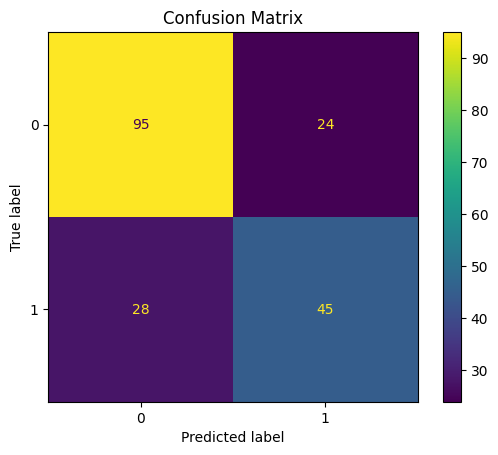

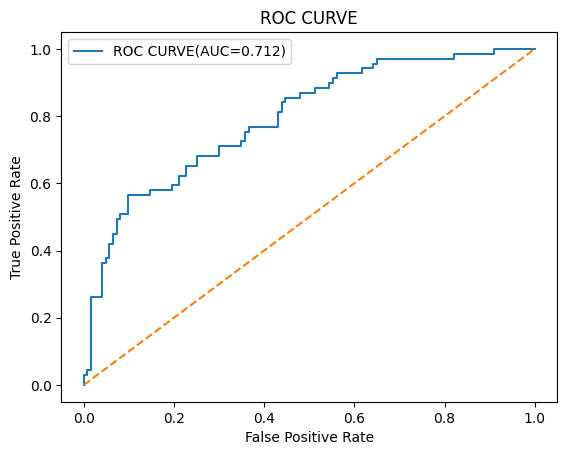

In [39]:
cm = confusion_matrix(y_pred,y_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix')
plt.show()
fpr,tpr,thresholds = roc_curve(y_test,y_prob[:,1])

roc_auc = roc_auc_score(y_test,y_pred)
plt.plot(fpr,tpr,label=f"ROC CURVE(AUC={roc_auc:.3f})")
plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC CURVE')
plt.legend()
plt.show()



MULTICLASS CLASSIFICATION

In [41]:
df = pd.read_csv('/workspaces/SML/SML /Exp 7/diabetes2.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [42]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [44]:
X = df.iloc[:,0:8]
y = df.iloc[:,8]


In [53]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [54]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_scaled= sc.fit_transform(X_train)
X_test_scaled= sc.transform(X_test)

In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
import numpy as np

# Initialize with penalty='elasticnet' to allow l1_ratio to work
# 'saga' is the only solver that supports the full l1_ratio range
classifier = LogisticRegression(penalty='elasticnet', solver='saga', max_iter=5000)

parameter = [
    {
        # This covers L1, L2, and everything in between (ElasticNet)
        'l1_ratio': [0.0, 0.5, 1.0], 
        'C': [0.1, 1, 10]
    },
    {
        # If you specifically need 'liblinear' (which doesn't use l1_ratio)
        # you can still define it separately like this:
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear'],
        'C': [0.1, 1, 10]
    }
]

grid = GridSearchCV(classifier, param_grid=parameter, cv=5)
grid.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...solver='saga')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': [0.1, 1, ...], 'l1_ratio': [0.0, 0.5, ...]}, {'C': [0.1, 1, ...], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and paramet

In [56]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_scaled)


In [57]:
from sklearn.metrics import accuracy_score
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.7447916666666666


In [58]:
from sklearn.metrics import classification_report
print("\nClassifcation Report:\n")
print(classification_report(y_test,y_pred))



Classifcation Report:

              precision    recall  f1-score   support

           0       0.78      0.83      0.81       123
           1       0.66      0.59      0.63        69

    accuracy                           0.74       192
   macro avg       0.72      0.71      0.72       192
weighted avg       0.74      0.74      0.74       192



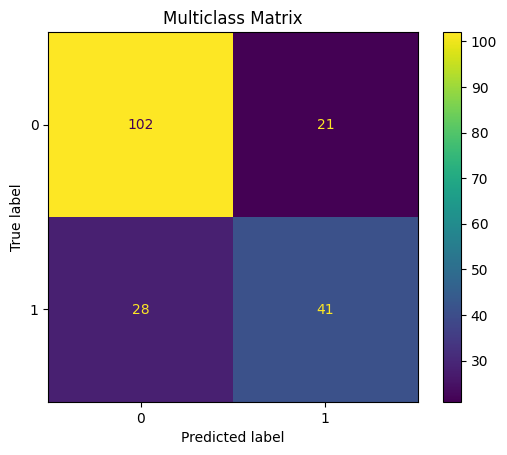

In [59]:
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=le.classes_)
disp.plot()
plt.title('Multiclass Matrix')
plt.show()

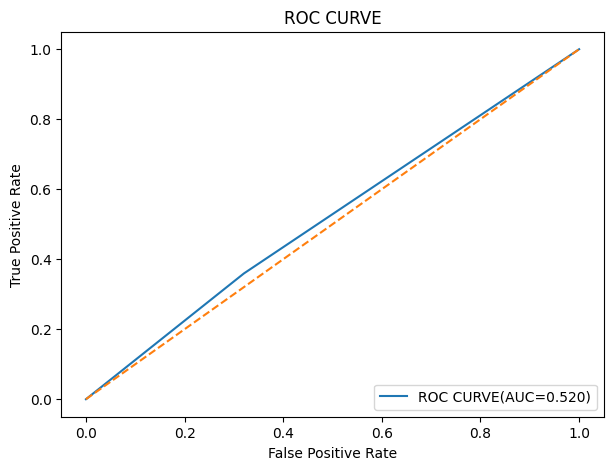

In [60]:
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# 1. Force the labels to have 3 columns (Shape: 25, 3)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# 2. Get your current scores (Shape: 25, 2)
y_score = best_model.predict_proba(X_test)


# We add a column of 0.0 for the missing class
if y_score.shape[1] == 2:
    zero_column = np.zeros((y_score.shape[0], 1))
    y_score_3 = np.hstack([y_score, zero_column])
else:
    y_score_3 = y_score

# 4. Flatten both to (75,) so they match perfectly
fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score_3.ravel())
roc_auc = auc(fpr, tpr)

# 5. Plotting to match your image exactly
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'ROC CURVE(AUC={roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC CURVE')
plt.legend(loc="lower right")
plt.show()